## Data Loading & Missing Data Handling

id                   0
age                  0
gender               0
country              0
cancer_stage         0
family_history       0
smoking_status       0
bmi                  0
cholesterol_level    0
hypertension         0
asthma               0
cirrhosis            0
other_cancer         0
treatment_type       0
survived             0
dtype: int64


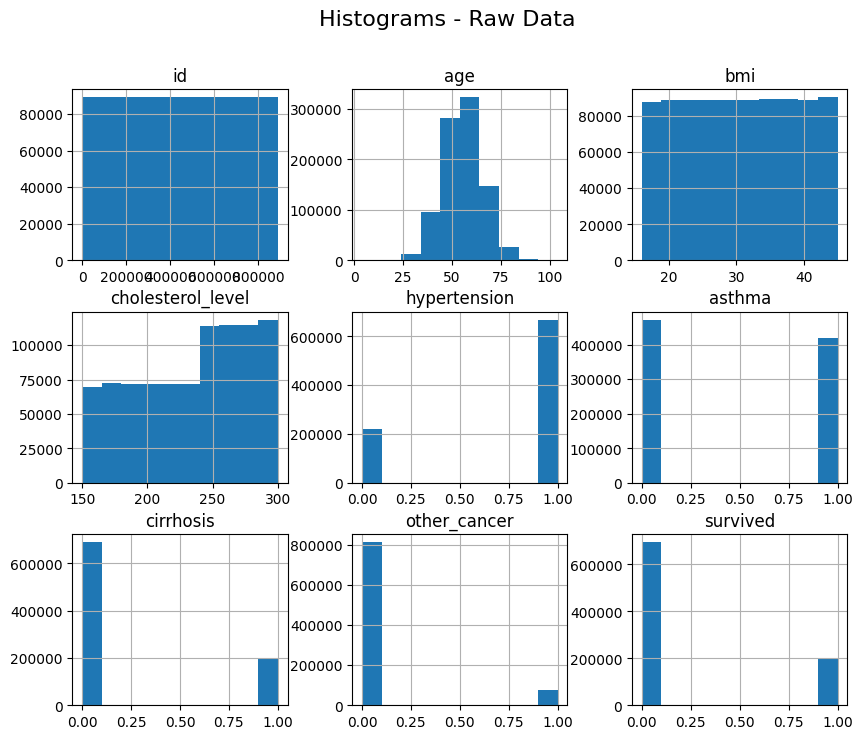

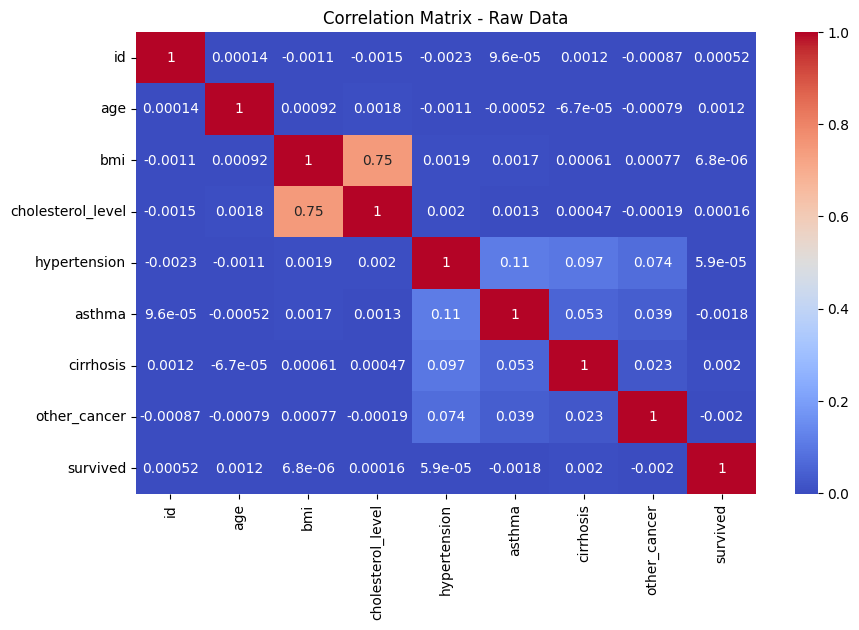

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("your_dataset.csv")

# Check for missing values
print(data.isnull().sum())

# Histograms before handling missing data
data.hist(figsize=(10, 8))
plt.suptitle("Histograms - Raw Data", fontsize=16)
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - Raw Data")
plt.show()




## Outlier Detection & Removal

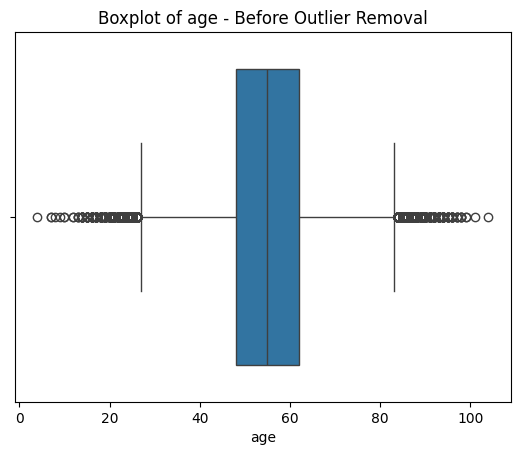

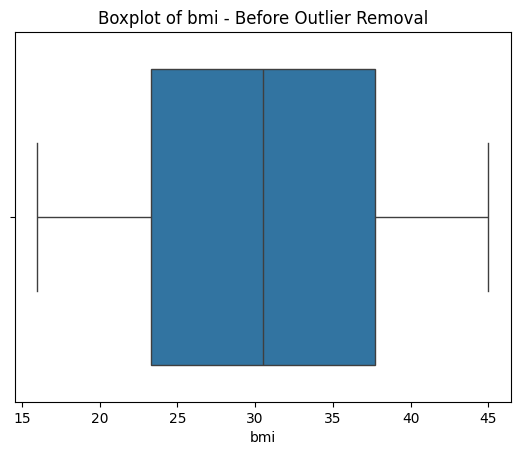

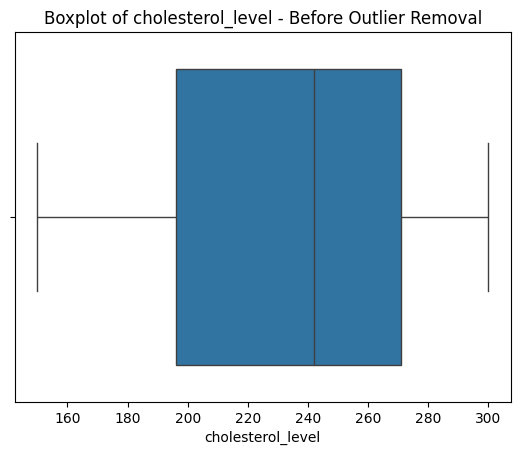

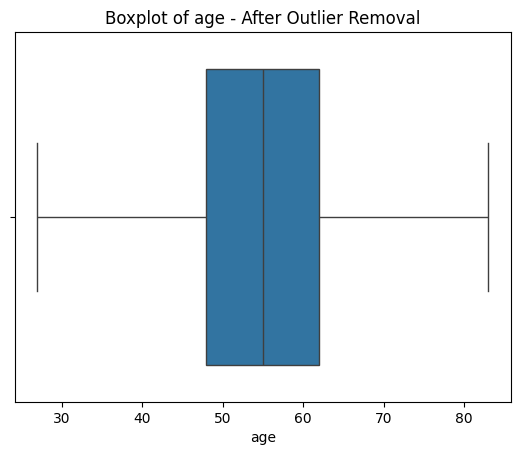

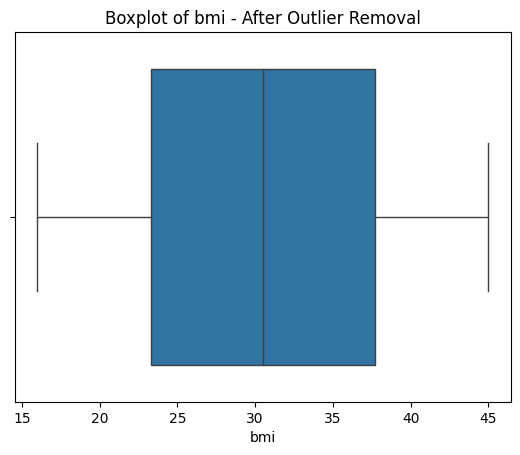

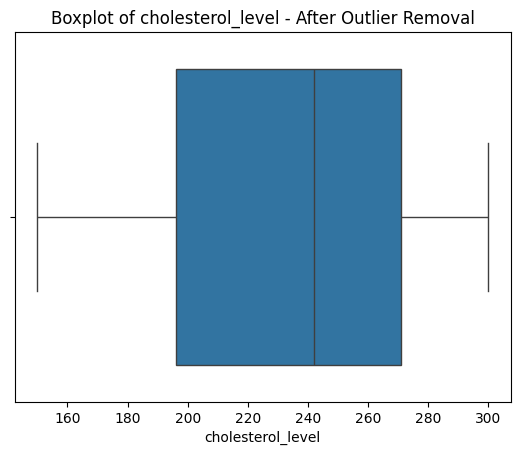

In [6]:
# Example visualization for outlier detection
numerical_features = ['age', 'bmi', 'cholesterol_level']

for col in numerical_features:
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col} - Before Outlier Removal")
    plt.show()

# Optionally remove outliers (IQR method example)
Q1 = data[numerical_features].quantile(0.25)
Q3 = data[numerical_features].quantile(0.75)
IQR = Q3 - Q1
data = data[~((data[numerical_features] < (Q1 - 1.5 * IQR)) |
              (data[numerical_features] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Boxplots after outlier removal
for col in numerical_features:
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col} - After Outlier Removal")
    plt.show()


## Class Balancing & Data Augmentation

Class distribution before balancing:
 survived
0    693996
1    196004
Name: count, dtype: int64
Class distribution after SMOTE:
 survived
0    693996
1    693996
Name: count, dtype: int64


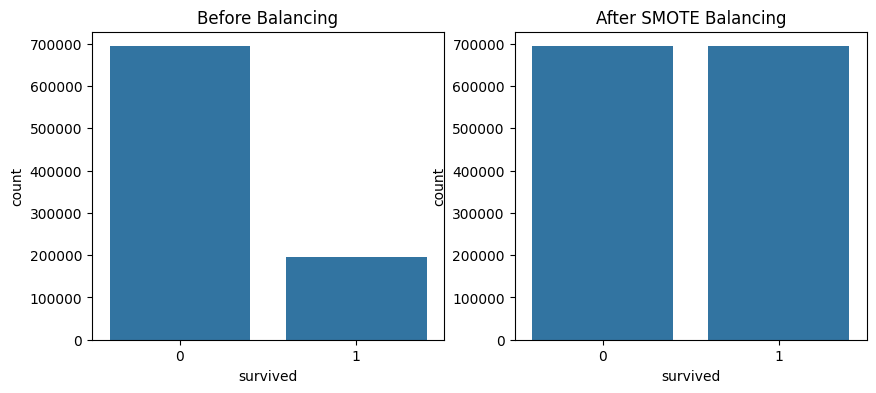

In [7]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Reload dataset (already done in previous cell, but keeping for clarity if run standalone)
data = pd.read_csv("your_dataset.csv")

# Print columns to check for date columns (for debugging if needed)
# print("Columns in the DataFrame after loading:", data.columns)

# Define X and y for resampling
X = data.drop(columns=['survived'])
y = data['survived']

# Show class distribution before balancing
print("Class distribution before balancing:\n", y.value_counts())

# Identify categorical and numerical features
categorical_features = ['gender', 'country', 'cancer_stage', 'smoking_status', 'treatment_type', 'family_history', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer']
numerical_features = ['age', 'bmi', 'cholesterol_level']


# Preprocessing pipeline for SMOTE
preprocessor_smote = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features), # Keep numerical features as they are
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop' # Drop other columns not specified in transformers
)

# Apply preprocessing
X_processed = preprocessor_smote.fit_transform(X)


# Random Under Sampling
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_processed, y)

# SMOTE Oversampling
smote = SMOTE(random_state=42)
X_res_sm, y_res_sm = smote.fit_resample(X_processed, y)

# Show class distribution after SMOTE
print("Class distribution after SMOTE:\n", y_res_sm.value_counts())

# Barplot before and after balancing
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y, ax=axes[0])
axes[0].set_title("Before Balancing")
sns.countplot(x=y_res_sm, ax=axes[1])
axes[1].set_title("After SMOTE Balancing")
plt.show()

## Normalization & Enhancement

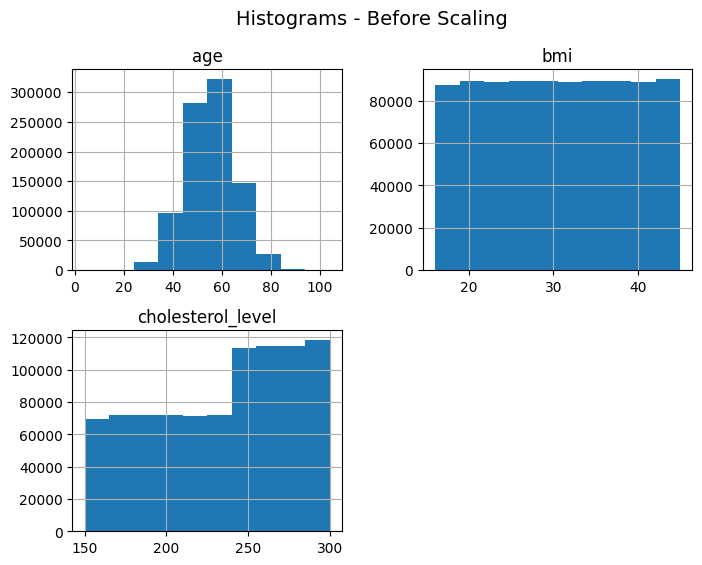

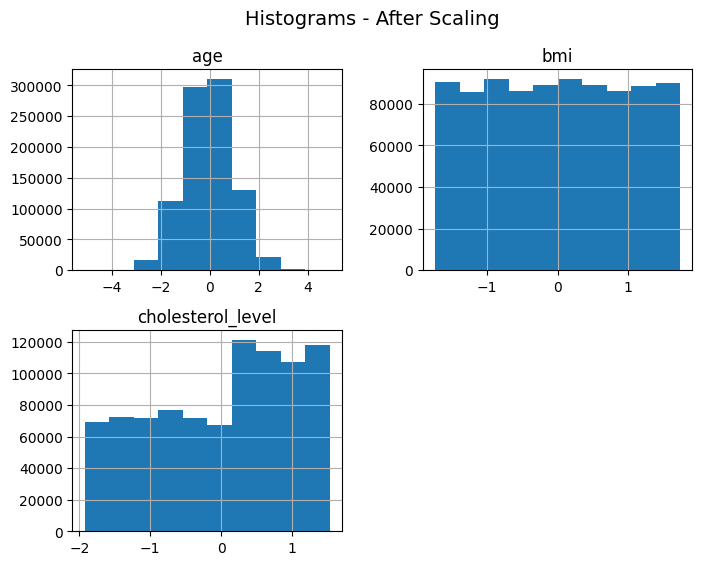

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical and numerical features
categorical_features = ['gender', 'country', 'cancer_stage', 'smoking_status', 'treatment_type', 'family_history', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer']
numerical_features = ['age', 'bmi', 'cholesterol_level']

# Histograms of numerical features before scaling
data[numerical_features].hist(figsize=(8, 6))
plt.suptitle("Histograms - Before Scaling", fontsize=14)
plt.show()

# Apply StandardScaler only to numerical features for visualization
scaler = StandardScaler()
scaled_numerical_data = scaler.fit_transform(data[numerical_features])

# Create a temporary DataFrame from scaled numerical data for plotting
scaled_df = pd.DataFrame(scaled_numerical_data, columns=numerical_features)

# Histograms after scaling
scaled_df.hist(figsize=(8, 6))
plt.suptitle("Histograms - After Scaling", fontsize=14)
plt.show()

# The preprocessor for the full dataset (including categorical) is defined but not used for plotting here
# It will be used later for data splitting and scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Note: X_scaled = preprocessor.fit_transform(X) would be used before model training
# but is not needed for this visualization step.

## Feature Engineering

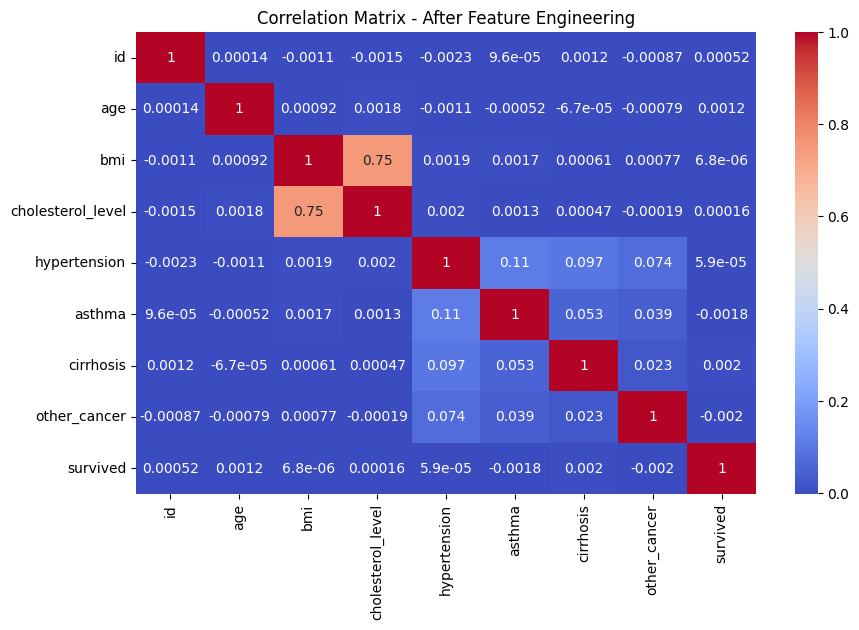

In [9]:
# Example: Creating new features
# This code is moved to cell 155f0d58 to ensure treatment_duration is created before resampling
# data['treatment_duration'] = (
#     pd.to_datetime(data['end_treatment_date']) - pd.to_datetime(data['diagnosis_date'])
# ).dt.days

# Drop irrelevant columns
# This code is moved to cell 155f0d58 to ensure treatment_duration is created before resampling
# data = data.drop(columns=['id', 'diagnosis_date', 'end_treatment_date'])

# Check correlation again after feature engineering
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - After Feature Engineering")
plt.show()

## Data Splitting & Scaling

In [10]:
import os
print(os.getcwd())                 # see current directory
os.makedirs('./results/outputs', exist_ok=True)
print(os.path.exists('./results/outputs'))   # should print True

/content
True


In [15]:
from sklearn.model_selection import train_test_split
import os
import re
import joblib


PROCESSED_DIR = "./results/outputs"

# Define features and target
X = data.drop(columns=['survived'])
y = data['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply preprocessing (scaling + encoding)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

joblib.dump(
      {
          "X_train": X_train_prep,   # preprocessed training features
          "X_test": X_test_prep,     #preprocessed testing features
          "y_train": y_train,        #training labels (target values)
         "y_test": y_test,          #testing labels
     },
      os.path.join(PROCESSED_DIR, "preprocessed_data.pkl")
  )


print("Train shape:", X_train_prep.shape)
print("Test shape:", X_test_prep.shape)

Train shape: (712000, 54)
Test shape: (178000, 54)
